In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset , DataLoader
import numpy as np
import matplotlib.pyplot as plt
import math
import torch.nn.functional as F
import torch.optim as optim
import tqdm

# Hipermeters defined
# Dataset Settings
NUM_SAMPLES_PER_MODAL = 200  #200 points per mod
BATCH_SIZE = 32

#Diffusion Settings
T_MAX_TIMESTEPS = 1000
T_EMBEDDING_DIM = 4


In [ ]:
components = [
    ( [1.0, 3.5], [[0.15, 0.0], [0.0, 0.15]], 0),
    ( [4.0, 3.0], [[0.15, 0.0], [0.0, 0.15]], 1),
    ( [1.5, 1.0], [[0.25, 0.0], [0.0, 0.25]], 1),
    ( [2.5, 2.0], [[0.35, 0.0], [0.0, 0.35]], 0),
    ( [4.5, 1.0], [[0.2, 0.0], [0.0, 0.2]], 1),
]

all_data = []
all_flags = []

for mean, cov, flag_value in components:
    # Data generation
    data_points = np.random.multivariate_normal(mean, cov, NUM_SAMPLES_PER_MODAL) #shape= (200,2)
    all_data.append(data_points)
    all_flags.append(np.ones(NUM_SAMPLES_PER_MODAL) * flag_value)

# Data & Flag concatenate
full_data_np = np.concatenate(all_data, axis=0) # 5*(200,2)= (1000,2)
full_flags_np = np.concatenate(all_flags, axis=0)



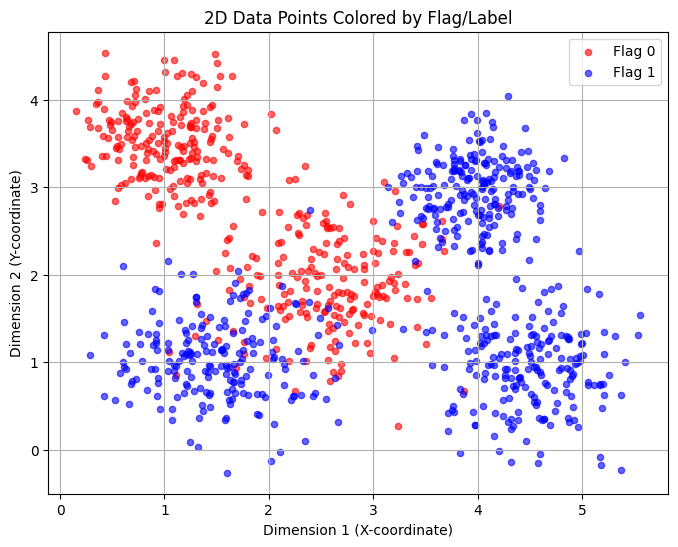

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Assumes full_data_np and full_flags_np are already generated ---
# full_data_np is (1000, 2)
# full_flags_np is (1000,)

# Separate the data points by their flag value for plotting
flag_0_mask = full_flags_np == 0
flag_1_mask = full_flags_np == 1

data_flag_0 = full_data_np[flag_0_mask]
data_flag_1 = full_data_np[flag_1_mask]

# Create the plot
plt.figure(figsize=(8, 6))

# Plot the points with flag 0 (e.g., in red)
plt.scatter(data_flag_0[:, 0], data_flag_0[:, 1],
            label='Flag 0',
            alpha=0.6,
            s=20, # point size
            color='red')

# Plot the points with flag 1 (e.g., in blue)
plt.scatter(data_flag_1[:, 0], data_flag_1[:, 1],
            label='Flag 1',
            alpha=0.6,
            s=20,
            color='blue')

# Add labels and title
plt.title('2D Data Points Colored by Flag/Label')
plt.xlabel('Dimension 1 (X-coordinate)')
plt.ylabel('Dimension 2 (Y-coordinate)')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

In [ ]:

X_tensor = torch.tensor(full_data_np, dtype=torch.float32)
F_tensor = torch.tensor(full_flags_np, dtype=torch.float32)

print(f"Total number of data points: {X_tensor.shape[0]}")
print(f"X (Data) tensor size: {X_tensor.shape}")
print(f"F (Flag) tensor size: {F_tensor.shape}")

# DataLoader Setup
dataset = TensorDataset(X_tensor, F_tensor)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

Total number of data points: 1000
X (Data) tensor size: torch.Size([1000, 2])
F (Flag) tensor size: torch.Size([1000])


In [ ]:
def get_time_embedding(timesteps, embedding_dim):
    half_dim = embedding_dim // 2
    emb = math.log(10000) / (half_dim - 1)
    emb = torch.exp(torch.arange(half_dim, device=timesteps.device) * -emb)
    emb = timesteps.float()[:, None] * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
    if embedding_dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb

def get_flag_embedding(flags):
    return flags.float()[:, None]


In [ ]:
# Mini Layer Class
class DenoisingBlock(nn.Module):

    def __init__(self, in_feat, out_feat):
        super().__init__()

        self.block = nn.Sequential(
            nn.Linear(in_feat, out_feat),
            nn.ReLU(),
            nn.LayerNorm(out_feat)
        )

    def forward(self, x):
        return self.block(x)


# Main Model Class
class DenoisingModel(nn.Module):
    def __init__(self, in_features=2, hidden_features=32, out_features=2, time_emb_dim=4):
        super().__init__()

        # Fixed embedding dimensions
        self.time_emb_dim = time_emb_dim
        self.flag_emb_dim = 1

        total_input_features = in_features + self.time_emb_dim + self.flag_emb_dim

        self.layer1 = DenoisingBlock(total_input_features, hidden_features)

        self.layer2 = DenoisingBlock(hidden_features, hidden_features)

        self.output_layer = nn.Linear(hidden_features, out_features)

    def forward(self, x, timesteps, flags):

        # 1. Embeddings generation
        time_emb = get_time_embedding(timesteps, self.time_emb_dim)
        flag_emb = get_flag_embedding(flags)

        # 2. Data, Time and Flag Concatenate
        combined_input = torch.cat([x, time_emb, flag_emb], dim=1)

        # 3. Forward Pass
        h = self.layer1(combined_input)
        h = self.layer2(h)

        # Output Layer (Estimated noise)
        output = self.output_layer(h)

        return output

In [ ]:
# 1. DIFFUSION SCHEDULE SETUP
# Defines the amount of noise to add (beta) at each timestep (t).
beta_start = 0.0001
beta_end = 0.02

# Linear schedule for beta (noise level)
betas = torch.linspace(beta_start, beta_end, T_MAX_TIMESTEPS)

# Alpha (signal retention)
alphas = 1.0 - betas

# Cumulative product of alphas (alpha_bar_t): The key term for forward diffusion
alpha_bars = torch.cumprod(alphas, dim=0)


In [ ]:
# 2. FORWARD DIFFUSION FUNCTION , Formula: x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * epsilon
def forward_diffusion(x0, t):
    sqrt_alpha_bar_t = torch.sqrt(alpha_bars[t])[:, None]
    sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bars[t])[:, None]

    # Generate pure Gaussian noise (epsilon)
    epsilon = torch.randn_like(x0)

    # Calculate the noisy data (x_t)
    x_t = sqrt_alpha_bar_t * x0 + sqrt_one_minus_alpha_bar_t * epsilon

    return x_t, epsilon


In [ ]:
# 3. MODEL INITIALIZATION AND OPTIMIZER
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DenoisingModel().to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

loss_fn = nn.MSELoss()

NUM_EPOCHS = 1000
loss_history = []

In [ ]:
# 4. THE CONDITIONAL TRAINING LOOP
print(f"Training started on {device} for {NUM_EPOCHS} epochs.")

for epoch in range(NUM_EPOCHS):
    total_loss = 0.0

    # Loop over the DataLoader batches
    for x0, flags in tqdm.tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False):

        # Move data to the device
        x0 = x0.to(device)
        flags = flags.to(device)

        # 1. Sample Timesteps (t)
        # Select a random timestep t for each data point in the batch
        t = torch.randint(
            0, T_MAX_TIMESTEPS, (x0.shape[0],), device=device
        )

        # 2. Forward Diffusion (Add Noise)
        x_t, epsilon = forward_diffusion(x0, t)

        # 3. Model Prediction (Denoising)
        # Input: Noisy data (x_t), Timestep (t), and Condition (flags)
        epsilon_predicted = model(x_t, t, flags)

        # 4. Compute Loss
        # Loss is calculated between the predicted noise (model output) and the actual noise
        loss = loss_fn(epsilon_predicted, epsilon)

        # 5. Backpropagation and Optimization
        optimizer.zero_grad() # Clear previous gradients
        loss.backward()       # Compute gradients
        optimizer.step()      # Update model parameters

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    loss_history.append(avg_loss)

    # Print loss periodically
    if (epoch + 1) % 100 == 0 or epoch == NUM_EPOCHS - 1:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} completed. Avg Loss: {avg_loss:.6f}")

print("Training Complete.")

Training started on cpu for 1000 epochs.


Epoch 100/1000 completed. Avg Loss: 0.305466


Epoch 200/1000 completed. Avg Loss: 0.287695


Epoch 300/1000 completed. Avg Loss: 0.295430


Epoch 400/1000 completed. Avg Loss: 0.225290


...

Epoch 600/1000 completed. Avg Loss: 0.223160


Epoch 700/1000 completed. Avg Loss: 0.273440


Epoch 800/1000 completed. Avg Loss: 0.248091


Epoch 900/1000 completed. Avg Loss: 0.250182


Epoch 1000/1000 completed. Avg Loss: 0.306687
Training Complete.


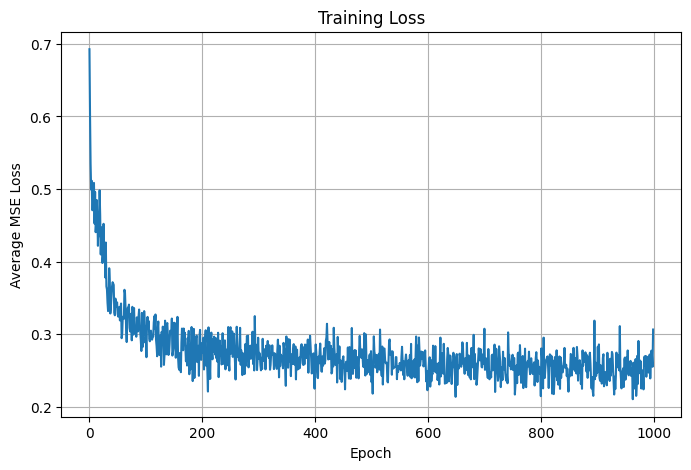

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Average MSE Loss")
plt.title("Training Loss")

plt.grid(True)
plt.show()

In [ ]:
import tqdm # Ensure tqdm is imported for progress bars

# Move diffusion schedule tensors to the device (CPU/GPU) for calculation
betas = betas.to(device)
alphas = alphas.to(device)
alpha_bars = alpha_bars.to(device)

def get_sampling_coefficients(t_index):
    """Calculates the necessary coefficients for the reverse diffusion step at index t_index."""

    alpha_t = alphas[t_index]
    alpha_bar_t = alpha_bars[t_index]
    # alpha_bar_t_minus_1 is alpha_bar at the previous step (t-1)
    alpha_bar_t_minus_1 = alpha_bars[t_index - 1] if t_index > 0 else torch.tensor(1.0).to(device)

    # Variance for the reverse process (beta_tilde_t)
    beta_tilde_t = (1.0 - alpha_bar_t_minus_1) / (1.0 - alpha_bar_t) * betas[t_index]

    # Coefficients for the mean calculation (mu_theta)
    coeff_noise = (1.0 - alpha_t) / torch.sqrt(1.0 - alpha_bar_t)
    coeff_xt = 1.0 / torch.sqrt(alpha_t)

    return coeff_xt, coeff_noise, beta_tilde_t

def sample_data(model, num_samples, T_MAX_TIMESTEPS, target_flag):
    """
    Generates new samples using the trained DenoisingModel conditioned on the target_flag.
    """
    model.eval() # Set model to evaluation mode
    with torch.no_grad():

        # 1. Start from pure Gaussian noise (x_T)
        x = torch.randn(num_samples, 2, device=device)

        # 2. Define the condition (Flag) for all samples
        flags = torch.ones(num_samples, device=device) * target_flag

        # 3. Reverse Diffusion Loop (Iterate from T down to 1)
        for t in tqdm.tqdm(range(T_MAX_TIMESTEPS, 0, -1), desc=f"Generating Flag {target_flag}"):

            # t-1 is the correct index for arrays (0 to T-1)
            t_index = t - 1
            t_tensor = torch.full((num_samples,), t_index, device=device)

            # Get reverse process coefficients
            coeff_xt, coeff_noise, beta_tilde_t = get_sampling_coefficients(t_index)

            # Model predicts the noise (epsilon) at time t
            epsilon_predicted = model(x, t_tensor, flags)

            # Reverse Diffusion Mean Calculation (mu_theta)
            # The model is used to estimate x_{t-1} from x_t
            mu_t = coeff_xt * (x - coeff_noise * epsilon_predicted)

            # Add variance (noise) if not the last step
            if t > 1:
                noise = torch.randn_like(x)
                sigma_t = torch.sqrt(beta_tilde_t)
                x = mu_t + sigma_t * noise
            else:
                # Last step (t=1): Use only the mean (mu_t) for the final clean sample x_0
                x = mu_t

        return x.cpu() # Return result to CPU

In [ ]:
samples_0 = sample_data(
    model,
    num_samples=200,
    T_MAX_TIMESTEPS=T_MAX_TIMESTEPS,
    target_flag=0
)

samples_1 = sample_data(
    model,
    num_samples=200,
    T_MAX_TIMESTEPS=T_MAX_TIMESTEPS,
    target_flag=1
)

Generating Flag 1: 100%|██████████| 1000/1000 [00:00<00:00, 2174.68it/s]


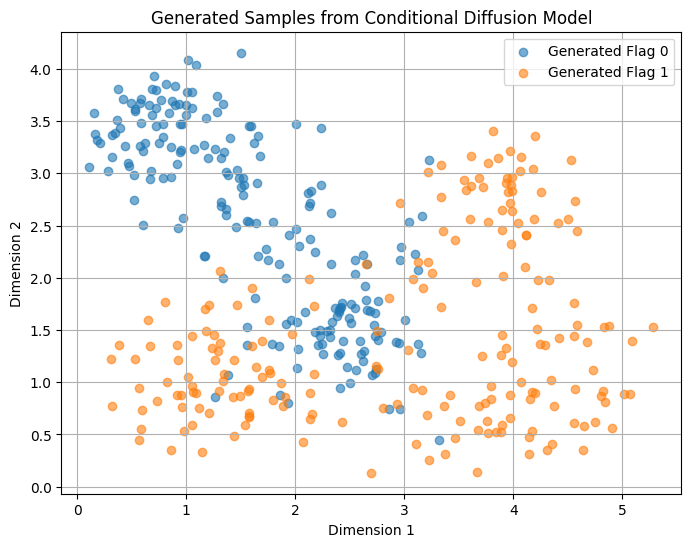

In [ ]:
samples_0_np = samples_0.numpy()
samples_1_np = samples_1.numpy()

plt.figure(figsize=(8, 6))

plt.scatter(
    samples_0_np[:, 0],
    samples_0_np[:, 1],
    alpha=0.6,
    label="Generated Flag 0"
)

plt.scatter(
    samples_1_np[:, 0],
    samples_1_np[:, 1],
    alpha=0.6,
    label="Generated Flag 1"
)

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("Generated Samples from Conditional Diffusion Model")

plt.legend()
plt.grid(True)
plt.show()